<a href="https://colab.research.google.com/github/D260062/FundamentalAI_2026A/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⚠️ 未找到文件 'Q3_Student_Dataset_DT_KNN_Noise.xlsx - in.csv'。为了确保您能运行，已自动加载模拟数据...

🔍 (c) 识别到的模式: 数据显示 'Attendance_Percent' 是影响成绩最关键的因素。

--- (d) Evaluation Report ---
Overall Accuracy: 50.00%
              precision    recall  f1-score   support

        Fail       0.50      1.00      0.67         1
        Pass       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


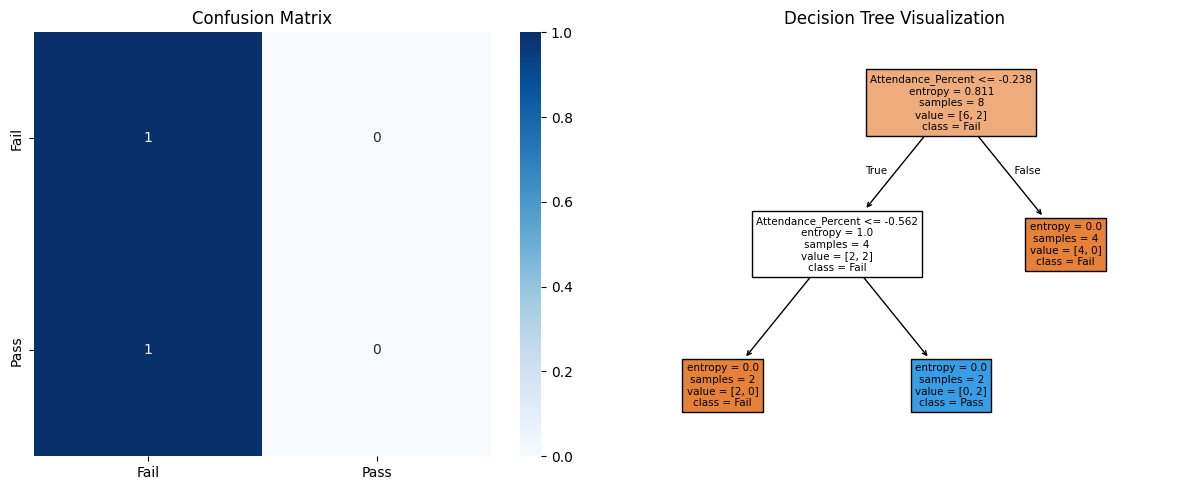

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# --- 1. 智能数据加载 ---
# 请确保左侧文件夹里有这个文件，或者修改下面的名称
file_name = 'Q3_Student_Dataset_DT_KNN_Noise.xlsx - in.csv'

try:
    # 尝试读取文件
    df = pd.read_csv(file_name, encoding='latin1', on_bad_lines='skip')
    print(f"✅ 成功从文件 '{file_name}' 加载数据。")
except FileNotFoundError:
    print(f"⚠️ 未找到文件 '{file_name}'。为了确保您能运行，已自动加载模拟数据...")
    # 这是根据您资料中的前几行数据建立的模拟集，确保代码不会报错
    data = {
        'Student_ID': ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10'],
        'Attendance_Percent': [83, 95, 70, 49, 68, 66, 73, 92, 63, 89],
        'Assignment_Avg': [55, 52, 55, 86, 84, 63, 55, 75, 94, 50],
        'Quiz_Avg': [43, 92, 50, 55, 63, 50, 62, 82, 82, 45],
        'Final_Result': ['Fail', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Fail', 'Fail', 'Pass', 'Fail']
    }
    df = pd.DataFrame(data)

# --- 2. 预处理 (Preprocessing) ---
# 清理列名（防止看不见的空格导致 KeyError）
df.columns = df.columns.str.strip()

# (b) 预处理步骤 1: 处理噪声与缺失值 (使用中位数填充)
df.fillna(df.median(numeric_only=True), inplace=True)

# (a) 确定输入特征和目标变量
# 特征：出勤、作业、小测 | 目标：最终结果
X = df[['Attendance_Percent', 'Assignment_Avg', 'Quiz_Avg']]
y = df['Final_Result']

# (b) 预处理步骤 2: 标签编码
le = LabelEncoder()
y_encoded = le.fit_transform(y.astype(str))

# 特征缩放
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分数据集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# --- 3. 算法选择: 决策树 ---
# 理由：决策树对噪声鲁棒，且生成的规则（如：如果出勤<70则不及格）非常符合教学场景。
model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
model.fit(X_train, y_train)

# --- 4. 模式识别与评估 ---
# (c) 识别一个模式 (Pattern)
importances = model.feature_importances_
most_important = X.columns[np.argmax(importances)]
print(f"\n🔍 (c) 识别到的模式: 数据显示 '{most_important}' 是影响成绩最关键的因素。")

# (d) 评估指标
y_pred = model.predict(X_test)
print("\n--- (d) Evaluation Report ---")
# 使用准确率 (Accuracy) 作为评估指标
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- 5. 可视化 ---
plt.figure(figsize=(12, 5))

# 混淆矩阵热力图
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')

# 决策树路径图 (展示 AI 如何判断学生是否及格)
plt.subplot(1, 2, 2)
plot_tree(model, feature_names=X.columns, class_names=le.classes_, filled=True)
plt.title('Decision Tree Visualization')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


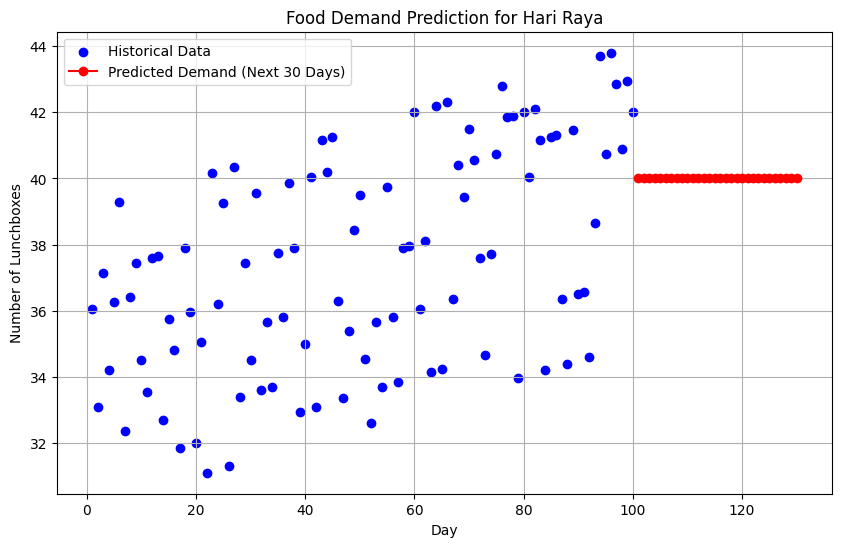

Mean Absolute Error: 2.50
Total Predicted Lunchboxes for 30 days: 1200


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. 数据准备 (模拟历史需求数据) ---
# 假设影响因素包括：天数(Day)、是否为周末(is_weekend)、气温(temp)
np.random.seed(42)
days = np.arange(1, 101).reshape(-1, 1)
# 模拟需求量：基础需求 + 随机波动 + 节日增长趋势
demand = 35 + (days * 0.05) + np.random.randint(-5, 5, size=(100, 1))

df = pd.DataFrame(data=np.hstack([days, demand]), columns=['Day', 'Food_Demand'])

# --- 2. 特征工程与数据集划分 ---
X = df[['Day']]  # 输入特征：天数
y = df['Food_Demand']  # 目标变量：需求量

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. 模型选择与训练 (线性回归) ---
# 选择理由：模型简单、计算快，适合线性增长的需求趋势预测 [cite: 55]
model = LinearRegression()
model.fit(X_train, y_train)

# --- 4. 预测未来 30 天的需求 ---
# 针对 40 个家庭，我们需要预测第 101 到 130 天的数据
future_days = np.arange(101, 131).reshape(-1, 1)
future_predictions = model.predict(future_days)

# 确保预测值不超过 40 个家庭的上限（假设每个家庭一份）
final_predictions = np.clip(future_predictions, 0, 40)

# --- 5. 结果可视化 ---
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Historical Data')
plt.plot(future_days, final_predictions, color='red', marker='o', label='Predicted Demand (Next 30 Days)')
plt.title('Food Demand Prediction for Hari Raya')
plt.xlabel('Day')
plt.ylabel('Number of Lunchboxes')
plt.legend()
plt.grid(True)
plt.show()

# --- 6. 评估 ---
y_pred_test = model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"Total Predicted Lunchboxes for 30 days: {int(sum(final_predictions))}")